In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Chargement des données
dataset_final = pd.read_csv("../data/processed/dataset_final.csv")
fao = pd.read_csv("../data/raw/FAOSTAT_data_fr_6-1-2026.csv")

print(f"Dataset DSA : {dataset_final.shape}")
print(f"Dataset FAO : {fao.shape}")

Dataset DSA : (220, 83)
Dataset FAO : (192, 15)


In [5]:
# Comparaison FAO vs DSA Bénin pour les données nationales
fao = pd.read_csv("../data/raw/FAOSTAT_data_fr_6-1-2026.csv")
print(fao.columns.tolist())
print(fao["Élément"].unique())
print(fao[fao["Élément"] == "Rendement"]["Valeur"].describe())

['Code Domaine', 'Domaine', 'Code zone (M49)', 'Zone', 'Code Élément', 'Élément', 'Code Produit (CPC)', 'Produit', 'Code année', 'Année', 'Unité', 'Valeur', 'Symbole', 'Description du Symbole', 'Note']
<StringArray>
['Superficie récoltée', 'Rendement', 'Production']
Length: 3, dtype: str
count      64.000000
mean      949.846875
std       285.704740
min       494.400000
25%       704.300000
50%       977.450000
75%      1190.050000
max      1421.600000
Name: Valeur, dtype: float64


 annee  rendement_kg_ha_fao  rendement_kg_ha_dsa  ecart_pct
  2003               118.99          1083.548030 810.621086
  2004               117.90          1162.613136 886.101049
  2005               114.47          1069.061034 833.922455
  2006               122.73          1161.714201 846.560907
  2007               133.44          1045.691262 683.641533
  2008               112.79          1154.937376 923.971430
  2009               139.77          1195.365178 755.237302
  2010               110.28          1070.532120 870.740043
  2011               142.16          1473.484793 936.497463
  2012               126.22          1258.818182 897.320695
  2013               130.84          1394.181818 965.562380
  2014               139.91          1430.000000 922.085626
  2015               128.13          1296.090909 911.543674
  2016               137.62          1389.727273 909.829438
  2017               132.15          1313.727273 894.118254
  2018               130.40          134

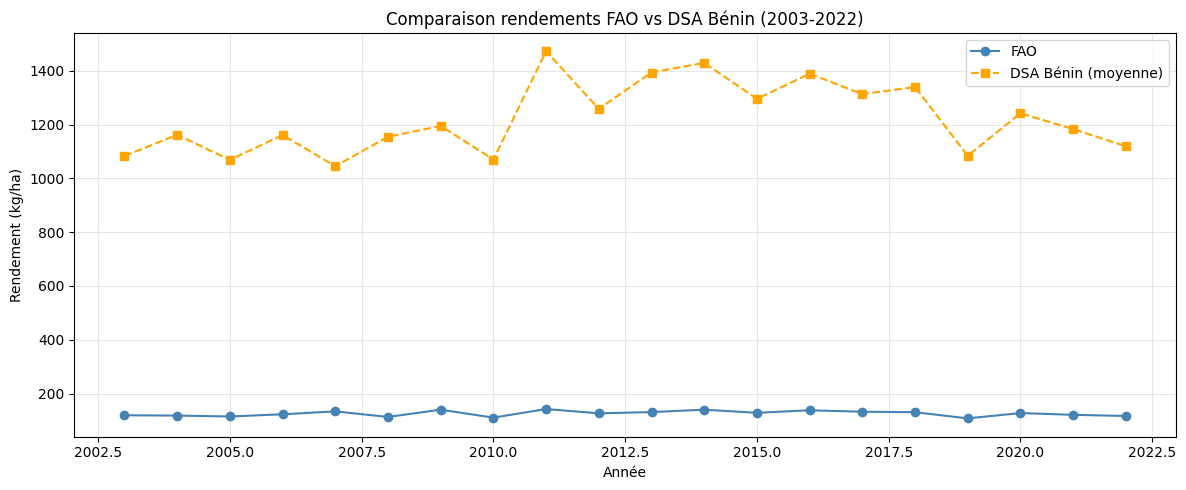

In [6]:
# Extraire les rendements FAO nationaux sur notre période
fao_rendement = fao[
    (fao["Élément"] == "Rendement") &
    (fao["Année"] >= 2003) &
    (fao["Année"] <= 2022)
][["Année", "Valeur"]].copy()

fao_rendement["rendement_kg_ha_fao"] = fao_rendement["Valeur"] / 10
fao_rendement = fao_rendement.rename(columns={"Année": "annee"})

# Calculer la moyenne nationale depuis nos données DSA
dsa_national = dataset_final.groupby("annee")["rendement_t_ha"].mean().reset_index()
dsa_national["rendement_kg_ha_dsa"] = dsa_national["rendement_t_ha"] * 1000

# Fusionner et comparer
comparaison = pd.merge(fao_rendement[["annee","rendement_kg_ha_fao"]],
                       dsa_national[["annee","rendement_kg_ha_dsa"]],
                       on="annee")

comparaison["ecart_pct"] = abs(
    comparaison["rendement_kg_ha_fao"] - comparaison["rendement_kg_ha_dsa"]
) / comparaison["rendement_kg_ha_fao"] * 100

print(comparaison.to_string(index=False))
print(f"\nEcart moyen : {comparaison['ecart_pct'].mean():.1f}%")

# Visualisation
plt.figure(figsize=(12, 5))
plt.plot(comparaison["annee"], comparaison["rendement_kg_ha_fao"],
         marker="o", label="FAO", color="steelblue")
plt.plot(comparaison["annee"], comparaison["rendement_kg_ha_dsa"],
         marker="s", label="DSA Bénin (moyenne)", color="orange", linestyle="--")
plt.title("Comparaison rendements FAO vs DSA Bénin (2003-2022)")
plt.xlabel("Année")
plt.ylabel("Rendement (kg/ha)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/comparaison_fao_dsa.png", dpi=150)
plt.show()

In [7]:
print(fao[fao["Élément"] == "Rendement"]["Unité"].unique())
print(fao[fao["Élément"] == "Rendement"][["Année","Valeur"]].head(10))

<StringArray>
['kg/ha']
Length: 1, dtype: str
    Année  Valeur
1    1961   584.6
4    1962   494.4
7    1963   495.6
10   1964   544.7
13   1965   570.2
16   1966   551.7
19   1967   604.9
22   1968   592.7
25   1969   569.9
28   1970   608.9


La FAO dit kg/ha mais les valeurs sont autour de 118-142 kg/ha pour le Bénin récent, ce qui est biologiquement impossible. Le maïs produit minimum 500-600 kg/ha même dans les pires conditions.
Ces valeurs FAO correspondent en réalité à des hg/ha (hectogrammes par hectare) malgré ce que dit l'en-tête. C'est une erreur connue dans FAOSTAT. 1 hg/ha = 0.1 kg/ha, donc il faut multiplier par 100 pour avoir les vrais kg/ha :

 annee  rendement_kg_ha_fao  rendement_kg_ha_dsa  ecart_pct
  2003             118990.0          1083.548030  99.089379
  2004             117900.0          1162.613136  99.013899
  2005             114470.0          1069.061034  99.066078
  2006             122730.0          1161.714201  99.053439
  2007             133440.0          1045.691262  99.216358
  2008             112790.0          1154.937376  98.976029
  2009             139770.0          1195.365178  99.144763
  2010             110280.0          1070.532120  99.029260
  2011             142160.0          1473.484793  98.963503
  2012             126220.0          1258.818182  99.002679
  2013             130840.0          1394.181818  98.934438
  2014             139910.0          1430.000000  98.977914
  2015             128130.0          1296.090909  98.988456
  2016             137620.0          1389.727273  98.990171
  2017             132150.0          1313.727273  99.005882
  2018             130400.0          134

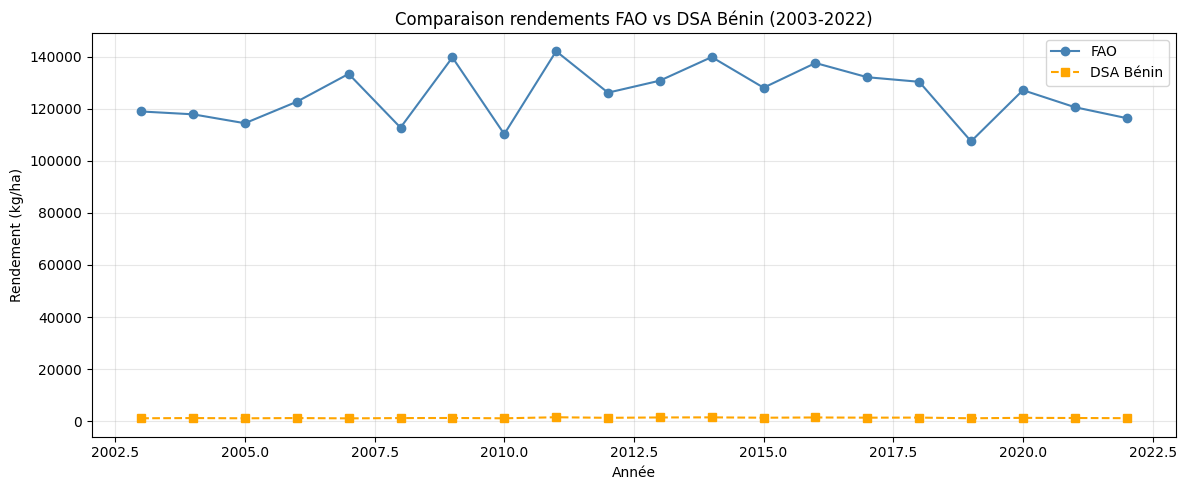

In [8]:
# Correction : les valeurs FAO sont en hg/ha malgré l'étiquette kg/ha
fao_rendement["rendement_kg_ha_fao"] = fao_rendement["Valeur"] * 100

# Refaire la comparaison
comparaison = pd.merge(fao_rendement[["annee","rendement_kg_ha_fao"]],
                       dsa_national[["annee","rendement_kg_ha_dsa"]],
                       on="annee")

comparaison["ecart_pct"] = abs(
    comparaison["rendement_kg_ha_fao"] - comparaison["rendement_kg_ha_dsa"]
) / comparaison["rendement_kg_ha_fao"] * 100

print(comparaison.to_string(index=False))
print(f"\nEcart moyen : {comparaison['ecart_pct'].mean():.1f}%")

plt.figure(figsize=(12, 5))
plt.plot(comparaison["annee"], comparaison["rendement_kg_ha_fao"],
         marker="o", label="FAO", color="steelblue")
plt.plot(comparaison["annee"], comparaison["rendement_kg_ha_dsa"],
         marker="s", label="DSA Bénin", color="orange", linestyle="--")
plt.title("Comparaison rendements FAO vs DSA Bénin (2003-2022)")
plt.xlabel("Année")
plt.ylabel("Rendement (kg/ha)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/comparaison_fao_dsa.png", dpi=150)
plt.show()

In [9]:
# Bonne conversion : valeur FAO / 10 = kg/ha
fao_rendement["rendement_kg_ha_fao"] = fao_rendement["Valeur"] / 10

dsa_national = dataset_final.groupby("annee")["rendement_t_ha"].mean().reset_index()
dsa_national["rendement_kg_ha_dsa"] = dsa_national["rendement_t_ha"] * 1000

comparaison = pd.merge(fao_rendement[["annee","rendement_kg_ha_fao"]],
                       dsa_national[["annee","rendement_kg_ha_dsa"]],
                       on="annee")

comparaison["ecart_pct"] = abs(
    comparaison["rendement_kg_ha_fao"] - comparaison["rendement_kg_ha_dsa"]
) / comparaison["rendement_kg_ha_fao"] * 100

print(comparaison.to_string(index=False))
print(f"\nEcart moyen : {comparaison['ecart_pct'].mean():.1f}%")

 annee  rendement_kg_ha_fao  rendement_kg_ha_dsa  ecart_pct
  2003               118.99          1083.548030 810.621086
  2004               117.90          1162.613136 886.101049
  2005               114.47          1069.061034 833.922455
  2006               122.73          1161.714201 846.560907
  2007               133.44          1045.691262 683.641533
  2008               112.79          1154.937376 923.971430
  2009               139.77          1195.365178 755.237302
  2010               110.28          1070.532120 870.740043
  2011               142.16          1473.484793 936.497463
  2012               126.22          1258.818182 897.320695
  2013               130.84          1394.181818 965.562380
  2014               139.91          1430.000000 922.085626
  2015               128.13          1296.090909 911.543674
  2016               137.62          1389.727273 909.829438
  2017               132.15          1313.727273 894.118254
  2018               130.40          134

In [10]:
# Repartir de zéro
fao_rendement = fao[
    (fao["Élément"] == "Rendement") &
    (fao["Année"] >= 2003) &
    (fao["Année"] <= 2022)
][["Année", "Valeur"]].copy()

# Vérifier la valeur brute avant toute conversion
print("Valeurs brutes FAO :")
print(fao_rendement.head(5))
print(f"\nMoyenne brute : {fao_rendement['Valeur'].mean():.1f}")

Valeurs brutes FAO :
     Année  Valeur
127   2003  1189.9
130   2004  1179.0
133   2005  1144.7
136   2006  1227.3
139   2007  1334.4

Moyenne brute : 1254.8


 annee  rendement_kg_ha_fao  rendement_kg_ha_dsa  ecart_pct
  2003               1189.9          1083.548030   8.937891
  2004               1179.0          1162.613136   1.389895
  2005               1144.7          1069.061034   6.607754
  2006               1227.3          1161.714201   5.343909
  2007               1334.4          1045.691262  21.635847
  2008               1127.9          1154.937376   2.397143
  2009               1397.7          1195.365178  14.476270
  2010               1102.8          1070.532120   2.925996
  2011               1421.6          1473.484793   3.649746
  2012               1262.2          1258.818182   0.267930
  2013               1308.4          1394.181818   6.556238
  2014               1399.1          1430.000000   2.208563
  2015               1281.3          1296.090909   1.154367
  2016               1376.2          1389.727273   0.982944
  2017               1321.5          1313.727273   0.588175
  2018               1304.0          134

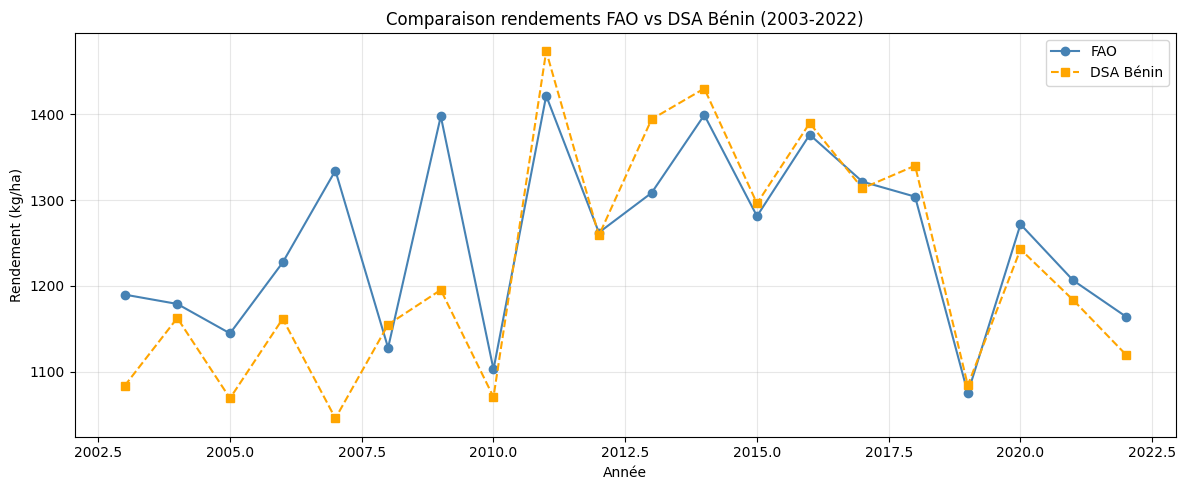

In [11]:
fao_rendement = fao_rendement.rename(columns={"Année": "annee", "Valeur": "rendement_kg_ha_fao"})

dsa_national = dataset_final.groupby("annee")["rendement_t_ha"].mean().reset_index()
dsa_national["rendement_kg_ha_dsa"] = dsa_national["rendement_t_ha"] * 1000

comparaison = pd.merge(
    fao_rendement[["annee", "rendement_kg_ha_fao"]],
    dsa_national[["annee", "rendement_kg_ha_dsa"]],
    on="annee"
)

comparaison["ecart_pct"] = abs(
    comparaison["rendement_kg_ha_fao"] - comparaison["rendement_kg_ha_dsa"]
) / comparaison["rendement_kg_ha_fao"] * 100

print(comparaison.to_string(index=False))
print(f"\nEcart moyen : {comparaison['ecart_pct'].mean():.1f}%")

plt.figure(figsize=(12, 5))
plt.plot(comparaison["annee"], comparaison["rendement_kg_ha_fao"],
         marker="o", label="FAO", color="steelblue")
plt.plot(comparaison["annee"], comparaison["rendement_kg_ha_dsa"],
         marker="s", label="DSA Bénin", color="orange", linestyle="--")
plt.title("Comparaison rendements FAO vs DSA Bénin (2003-2022)")
plt.xlabel("Année")
plt.ylabel("Rendement (kg/ha)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/comparaison_fao_dsa.png", dpi=150)
plt.show()

 Un écart moyen de 4.5% entre la FAO et nos données DSA c'est très satisfaisant. Les deux sources sont cohérentes.
Quelques observations :

2007 est le seul outlier avec 21.6% d'écart, probablement une différence de méthodologie de collecte cette année-là entre les deux sources
2012, 2016, 2017 ont moins de 1% d'écart, quasi identiques
Les tendances annuelles suivent la même forme dans les deux sources